# POC 04 — three training schedules: all-months, commissioning, streaming

POC_02 v4 settled the preprocessing question: with **flow orientation** the global model
reconstructs (median window r 0.62 against 0.03), FedAvg stops costing shape (local − global
r ≈ 0.00), and other clients' local models transfer (`r_cross` 0.24–0.86). What it left
standing:

* the **drifting client** goes flat exactly in the months it drifts (A's pure `shape_amp`
  0.66 in init, 0.08 in transition, 0.06 in final);
* **bidirectional** mixed sensors stay weak;
* the weekly (weekend) modulation is missing from single-window reconstructions, so the
  prototypes cannot have it either — `ceiling` = `aligned` at r_shape 0.64;
* **every model has seen the whole horizon**, so describing month 20 uses months 21–64.

This notebook compares three schedules on the same world, selection, geometry and scaler:

| cell | schedule | what it means |
|---|---|---|
| `all` | none | the POC_02 setting: every month, every round |
| `comm` | `Schedule("commissioning", months=init)` | trained on the init months, then frozen; the rest is only encoded |
| `stream` | `Schedule("streaming", block_months=B, rounds_per_block=R)` | prequential: score the next block unseen, then train on it, carrying weights and prototypes |

Every POC_02 analysis is run on all three, and §8 asks the thesis question directly: which
schedule makes the drift most visible in the artifacts while leaving the other clients alone.

**Defaults carried over from v4:** `orient=True`, geometry `a3w84s4`, and the two objectives
that did best (`pw0` reconstruction-only, and `pw.1+s` with the spectral term, which was much
the best on the drifting client: r_pure 0.71 against 0.25).

## 0. Setup

In [1]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms, Schedule
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR, localeval as LE
from fedwater_lab import streaming as ST, compare as CP

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

REQUIRE_GPU = True
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if REQUIRE_GPU:
    assert torch.cuda.is_available(), "no CUDA device visible to torch"

2.5.1+cu124 12.4 True


## 1. World, sensors, orientation

In [4]:
BASE

CellSpec(kinds=('flow',), classes=('pure', 'mixed'), include=(), exclude=(), transform='none', scaling='minmax_ref', geometry=Geometry(interval_agg_h=3, window_size=84, step_size=4, reference_months=None, label_threshold=0.75, feature_range=(-1.0, 1.0)), model=ModelCfg(lstm_units=30, reg_ratio=0.5), training=TrainCfg(rounds=5, local_epochs=1, learning_rate=0.001, batch_size=64, participation=1.0, averaging='equal', proto_alpha=0.2, infonce_temperature=0.02, fl_seed=0, device='auto', proto_weight=None), noise=False, cap=3000, snapshot_rounds='sparse', snapshot_points=1500, keep_weights='final', loss_terms=None, orient=True, schedule=None)

In [6]:
FILTERS = dict(sim_hash="f335b2cfad67", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary()[["tag", "n_months", "init_months", "final_months",
                       "drift_district", "first_switch", "last_switch"]].to_string())

GEOM = Geometry(interval_agg_h=3, window_size=84, step_size=4)
BASE = POC.with_(kinds=("flow",), classes=("pure", "mixed"), orient=True, geometry=GEOM)

OT = D.orientation_table(world, BASE)
display(OT[["client", "slot", "sensor", "tier", "purity", "sign", "frac_rev_ref",
            "bidirectional"]].round(3))
display(D.channel_alignment(world, BASE))
AUDIT = store.audit(world.sim_hash)
if not AUDIT["ok"].all():
    display(AUDIT[~AUDIT["ok"]])
    print("set PURGE below to remove these before training")
PURGE = False
if PURGE:
    print("purged:", store.purge(world.sim_hash, AUDIT.loc[~AUDIT["ok"], "run_key"]))

tag               District_A__LR_LR_LC_LI__baseline
n_months                                         70
init_months                                   0..11
final_months                                 53..69
drift_district                           District_A
first_switch                                     12
last_switch                                      52


,client,slot,sensor,tier,purity,sign,frac_rev_ref,bidirectional
0,District_A,q_mixed_0,q_P-94,foreign,0.000,-1.0,0.459,True
1,District_A,q_mixed_1,q_P-558,foreign,0.000,-1.0,0.487,True
2,District_A,q_pure_0,q_P-42,core,1.000,-1.0,0.000,False
3,District_A,q_pure_1,q_P-44,core,1.000,-1.0,0.000,False
4,District_B,q_mixed_0,q_P-329,transition,0.732,-1.0,0.471,True
5,District_B,q_mixed_1,q_P-260,foreign,0.129,1.0,0.430,True
6,District_B,q_pure_0,q_P-30,core,1.000,1.0,0.000,False
7,District_B,q_pure_1,q_P-285,core,1.000,-1.0,0.000,False
8,District_C,q_mixed_0,q_P-509,transition,0.438,-1.0,0.000,False
9,District_C,q_mixed_1,q_P-571,foreign,0.000,1.0,0.443,True


client,District_A,District_B,District_C,District_D
channel,,,,
0,q_mixed_0 · foreign · p0.00 · +District_D · - ...,q_mixed_0 · transition · p0.73 · +District_A ·...,q_mixed_0 · transition · p0.44 · +District_B · -,q_mixed_0 · core · p1.00 · +
1,q_mixed_1 · foreign · p0.00 · +District_B · - ...,q_mixed_1 · foreign · p0.13 · +District_D · + ...,q_mixed_1 · foreign · p0.00 · +District_A · + ...,q_mixed_1 · core · p1.00 · +
2,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · +
3,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · +


KeyError: 'ok'

## 2. The three schedules

**Equal budgets, not equal rounds.** A commissioning cell trains on the init months only and a
streaming cell on one block at a time, so the same `rounds` buys very different numbers of
optimiser steps. `ST.step_plan` reports the steps each spec will run, and
`ST.rounds_for_steps` picks rounds to hit a target. `TARGET_STEPS` is the common budget
(v4's `s4` cells ran about 2,850 steps per client).

**What carries across blocks in streaming:** the global weights, each client's local weights,
and the accumulated global prototypes (so the contrastive term of block *b* pulls towards
prototypes computed on earlier regimes — which is what makes a change show up as a pull away
from them). Adam moments restart per block, because the upstream trainer builds its
optimisers with its data.

The first block trains for `warm_rounds` so the model does not enter block 1 untrained.

In [7]:
TARGET_STEPS = 2850
INIT_LO, INIT_HI = world.phases()["init"][0], world.phases()["init"][1] - 1
BLOCK_MONTHS = 6

OBJ = {"pw0": LossTerms(proto_weight=0.0),
       "pw.1+s": LossTerms(proto_weight=0.1, spec=1.0)}

fw_all, _, fl_all = D.build_windows(world, BASE, cache=D.CACHE)
print({c: len(d["labels"]) for c, d in fw_all.items()}, "windows/client")

CELLS, PLAN = {}, []
for oname, lt in OBJ.items():
    base = BASE.with_(loss_terms=lt, **{"training.rounds": 30, "training.local_epochs": 5})
    cand = {
        "all": base,
        "comm": base.with_(schedule=Schedule(mode="commissioning",
                                             months=(INIT_LO, INIT_HI))),
        "stream": base.with_(schedule=Schedule(mode="streaming",
                                               block_months=BLOCK_MONTHS,
                                               rounds_per_block=5)),
    }
    # match the step budget
    r_comm = ST.rounds_for_steps(cand["comm"], fw_all, fl_all, TARGET_STEPS)
    cand["comm"] = cand["comm"].with_(**{"training.rounds": r_comm})
    r_str = ST.rounds_for_steps(cand["stream"], fw_all, fl_all, TARGET_STEPS)
    cand["stream"] = cand["stream"].with_(
        schedule=Schedule(mode="streaming", block_months=BLOCK_MONTHS,
                          rounds_per_block=max(1, r_str // len(
                              ST.month_blocks(range(world.n_months), BLOCK_MONTHS))),
                          warm_rounds=10))
    for sname, sp in cand.items():
        key = f"{oname}·{sname}"
        CELLS[key] = sp
        PLAN.append({"cell": key, **ST.step_plan(sp, fw_all, sp.as_fl(
            world.fl, reference_months=world.warmup_months)),
            "label": sp.label(), "in store": store.exists(world, sp)})

display(pd.DataFrame(PLAN).round(1))
TRAIN = list(CELLS)

{'District_A': 1250, 'District_B': 1250, 'District_C': 1250, 'District_D': 1250} windows/client


,cell,mode,windows_per_pass,batches,rounds,steps,label,in store
0,pw0·all,all,1250.0,20,30,3000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
1,pw0·comm,C0-11,211.0,4,712,14240,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,False
2,pw0·stream,S6x118w10,104.2,2,1416,13080,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
3,pw.1+s·all,all,1250.0,20,30,3000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
4,pw.1+s·comm,C0-11,211.0,4,712,14240,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,False
5,pw.1+s·stream,S6x118w10,104.2,2,1416,13080,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False


In [ ]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    res = run_cell(world, spec, store=store, verbose=False)
    bad = T.fl_mismatches(spec, res["fl"])
    assert not bad, f"{name}: stored run trained with {bad}"
    RUNS[name] = res["run_key"]
    print(f"{name:<14} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"rounds={res['meta'].get('rounds')}  "
          f"train_windows={res['meta'].get('train_windows')}  {time.time() - t0:.0f}s")

pw0·all        6a52b826462d  cache_hit=False  rounds=30  train_windows=1250.0  569s
pw0·comm       d8285c34a0e2  cache_hit=False  rounds=712  train_windows=211.0  3059s


## 3. Sanity, per cell

The v4 columns, plus `schedule` and a `steps/client` that now counts the windows the cell
actually trained on. `sanity` asserts that each stored run's `fl` and log match its spec, and
the untrained control is the same round −1 model for all of them.

,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream
label,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...
run_key,834f3f95df95,c307ec4b2405,4baaf84b3c05,9eee1daa043c,19ad4c258449,7a43014bbc7d
schedule,all,C0-11,S6x129w10,all,C0-11,S6x129w10
steps/client,2850,14240,13000,2850,14240,13000
loss_mse_last,0.07175,0.004274,0.014714,0.170365,0.030858,0.107726
d_mse_last,0.096963,-0.021651,-0.158625,-0.113413,-0.011787,0.002528
aux_share,0.0,0.0,0.0,0.511616,0.692153,0.423006
final_over_wmean,0.457274,0.783123,0.30891,1.092585,0.901375,0.560676
final_over_const,0.395791,0.560848,0.264782,0.96567,0.661571,0.495871
window_amp,0.754733,1.020235,0.903192,0.615475,1.001592,0.761995


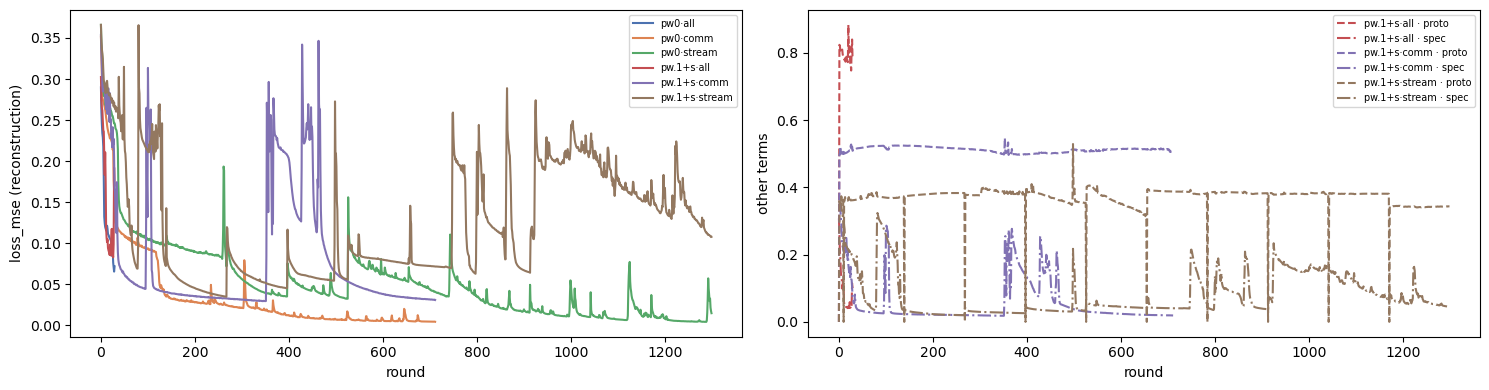

In [ ]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN, MM = {}, {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    ch = RC.channel_table(world, OUTS[name]["fw"])
    MM[name] = LE.model_matrix(world, OUTS[name], ch, store=store)
    SAN[name]["row"] = pd.concat([SAN[name]["row"], pd.Series(LE.lg_row(MM[name]))])
    assert OUTS[name]["checks"]["passed"].all()
    assert SAN[name]["control_check"]["passed"].all()

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

## 4. Focus cell, and local vs global

`FOCUS` selects the cell the detailed sections read. The gap table and the model × client
matrices are v4's: rows are models (global, then each client's local weights), columns are the
client whose windows are reconstructed.

fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0__Lp0.1-s1__C0-11


client,District_A,District_B,District_C,District_D
ratio_global,2.279,0.489,0.746,0.091
ratio_local,2.183,0.456,0.715,0.069
ratio_cross,2.314,0.519,0.773,0.120
amp_global,1.057,0.968,0.960,0.931
amp_local,1.013,0.969,0.954,0.965
amp_cross,1.077,0.968,0.965,0.923
r_global,0.475,0.905,0.891,0.939
r_local,0.549,0.907,0.898,0.944
r_cross,0.393,0.899,0.884,0.929
r_pure_global,0.327,0.927,0.914,0.941


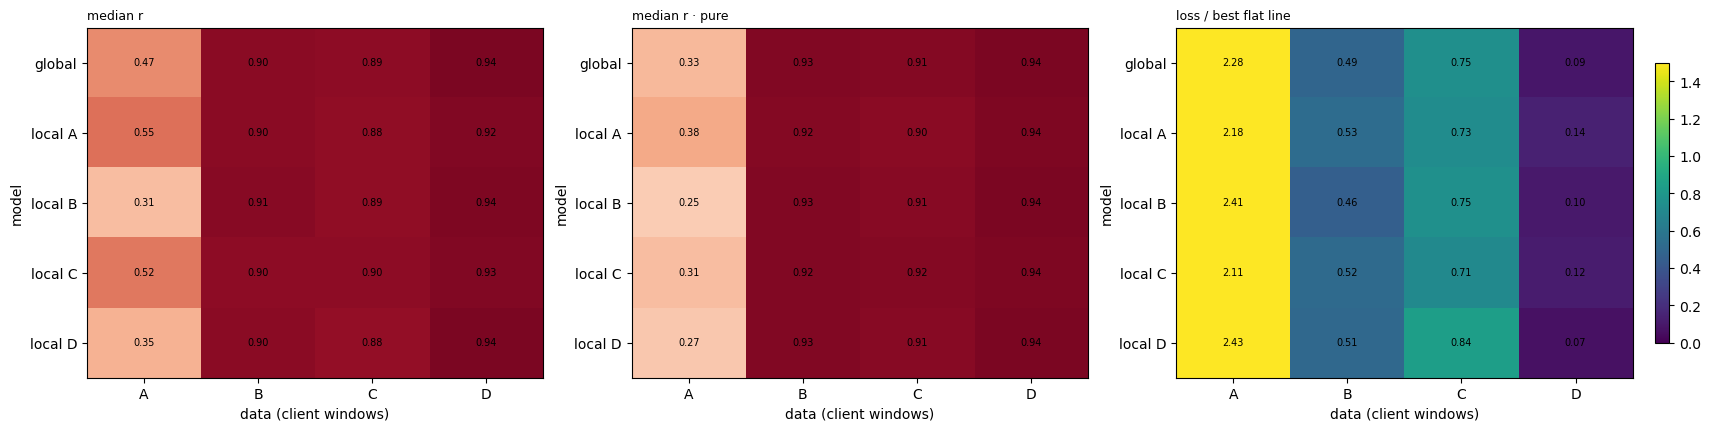

In [ ]:
FOCUS = "pw.1+s·comm"
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
channels = RC.channel_table(world, fw)
LOCAL = LE.local_runs(world, out, store=store)
mm = MM[FOCUS]
print(CELLS[FOCUS].label())

display(LE.gap_table(mm).set_index("client").round(3).T)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), layout="constrained")
LE.plot_matrix(axes[0], mm, "r", title="median r")
LE.plot_matrix(axes[1], mm, "r_pure", title="median r · pure")
im = LE.plot_matrix(axes[2], mm, "ratio", vmin=0, vmax=1.5, cmap="viridis",
                    title="loss / best flat line")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.show()

## 5. Window reconstruction

Per-window scores for the focus cell (global, local, untrained), then the month × start-class
grids and the position profiles. **Read the phase split:** a commissioning model is expected
to lose fidelity after the drift — that is the signal, not a failure.

pw0·all               pw0·comm               pw0·stream               pw.1+s·all               pw.1+s·comm               pw.1+s·stream              
                            r    amp   rmse        r    amp   rmse          r    amp   rmse          r    amp   rmse           r    amp   rmse             r    amp   rmse
phase      slot_class                                                                                                                                                     
final      mixed        0.326  0.568  0.448    0.685  1.051  0.431      0.968  0.909  0.139      0.007  0.593  0.607       0.547  0.986  0.464         0.466  0.728  0.488
           pure         0.933  0.917  0.223    0.931  0.999  0.214      0.986  0.973  0.097      0.065  0.653  0.687       0.916  0.979  0.241         0.699  0.847  0.414
init       mixed        0.601  0.548  0.504    0.992  0.978  0.079      0.718  0.703  0.455      0.047  0.540  0.671       0.917  0.936  0.243         0.367  0.592  0.598
           pure         0.932  0.964  0.217    0.994  0.991  0.064      0.940  0.970  0.203      0.099  0.665  0.678       0.938  0.960  0.206         0.670  0.832  0.450
transition mixed        0.472  0.516  0.472    0.679  0.980  0.451      0.798  0.832  0.312      0.042  0.569  0.654       0.578  0.924  0.452         0.400  0.674  0.532
           pure         0.932  0.936  0.225    0.945  0.997  0.193      0.971  0.969  0.141      0.087  0.655  0.673       0.922  0.975  0.233         0.687  0.838  0.432

global         local       
                           r    amp      r    amp
client     slot_class                            
District_A mixed       0.519  0.988  0.575  0.968
           pure        0.327  1.227  0.375  1.222
District_B mixed       0.615  0.942  0.625  0.960
           pure        0.927  0.974  0.927  0.972
District_C mixed       0.447  0.933  0.450  0.927
           pure        0.914  0.973  0.917  0.969
District_D mixed       0.935  0.899  0.943  0.975
           pure        0.941  0.951  0.944  0.954

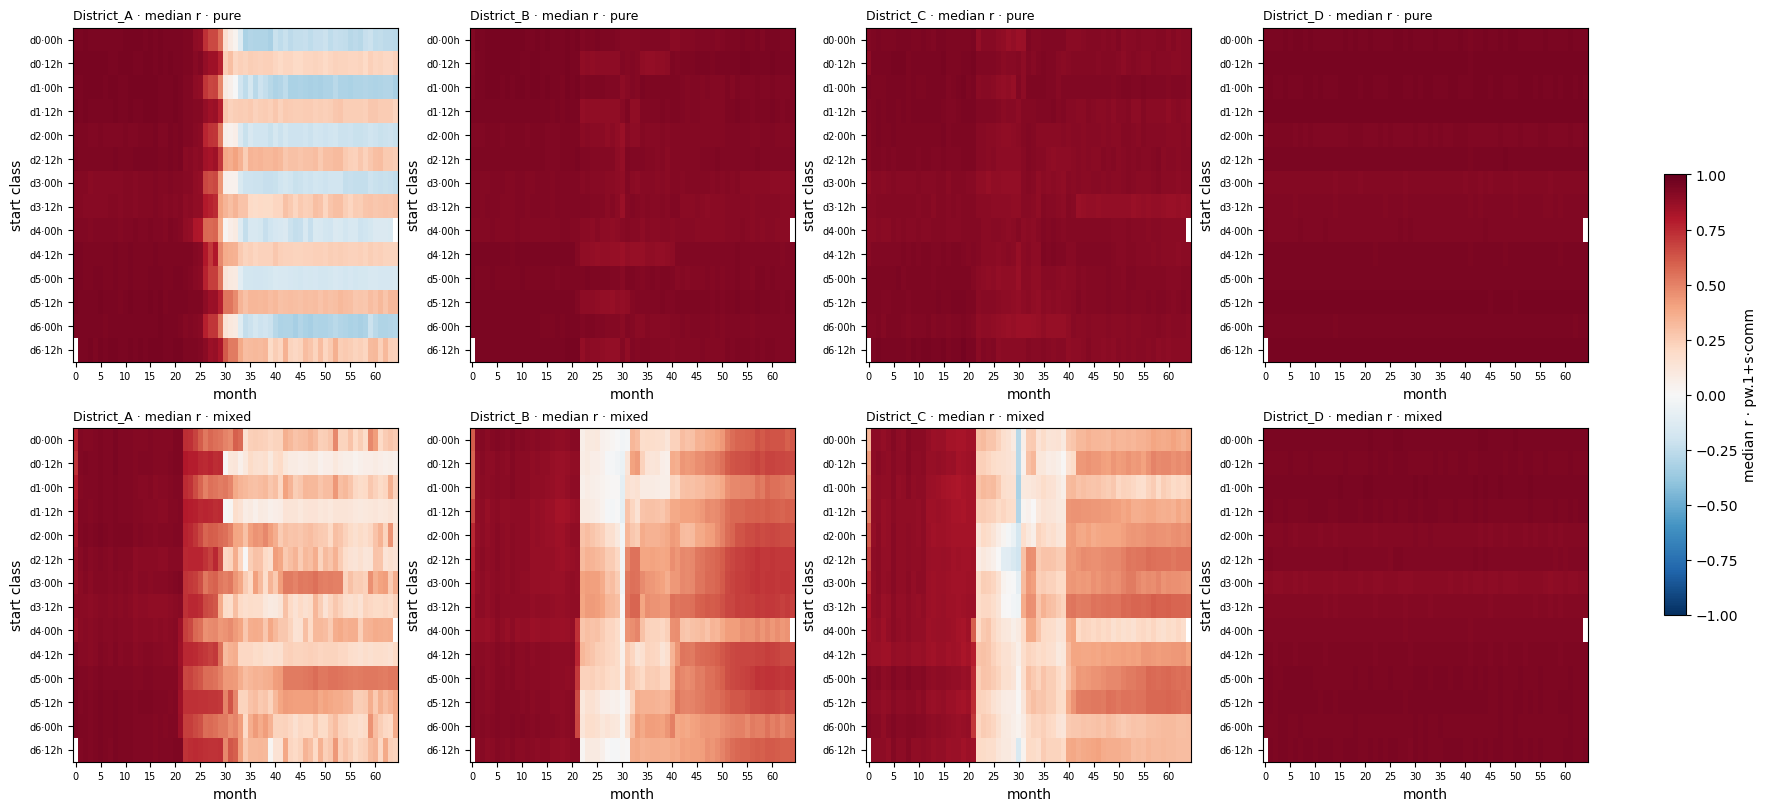

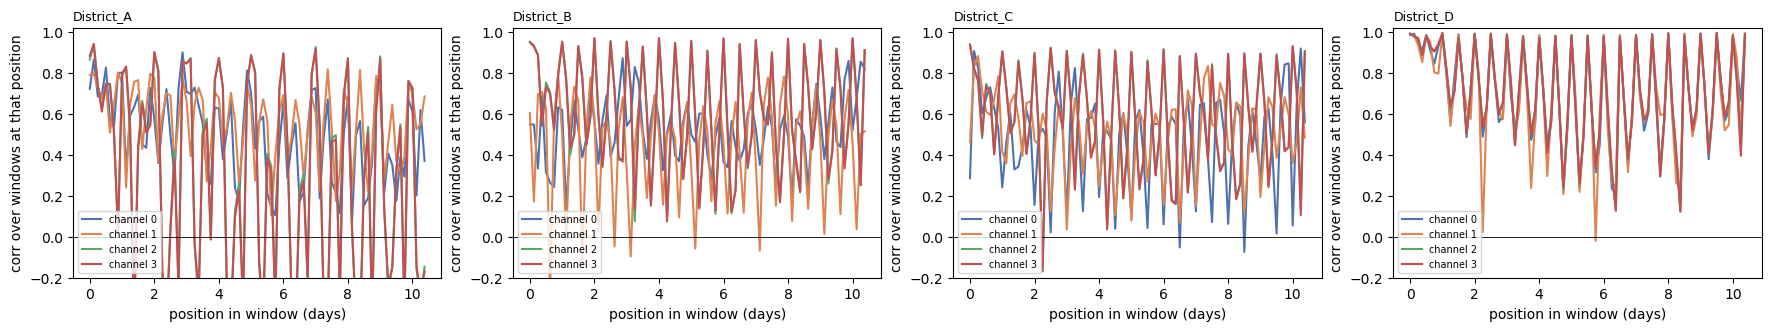

In [ ]:
WS = {k: WR.window_scores(OUTS[k]["run"], OUTS[k]["fw"], channels) for k in OUTS}
display(pd.concat({k: v.groupby(["phase", "slot_class"])[["r", "amp", "rmse"]].median()
                   for k, v in WS.items()}, axis=1).round(3))

ws, ws_l = WS[FOCUS], pd.concat([WR.window_scores(LOCAL[c], {c: fw[c]}, channels)
                                 for c in LOCAL])
display(pd.concat({"global": ws.groupby(["client", "slot_class"])[["r", "amp"]].median(),
                   "local": ws_l.groupby(["client", "slot_class"])[["r", "amp"]].median()},
                  axis=1).round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], ws, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label=f"median r · {FOCUS}")
plt.show()

fig, axes = plt.subplots(1, len(clients), figsize=(4.4 * len(clients), 3.2), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    WR.plot_step_profile(axes[0, j], WR.step_profile(run, fw, c), run.agg_h, title=c)
plt.show()

In [ ]:
BROWSE = "District_A"
_ = WR.window_browser(LOCAL[BROWSE], {BROWSE: fw[BROWSE]},
                      ws_l[ws_l["client"] == BROWSE], channels,
                      ctrl=run, ctrl_label="global model", run_label="local model")

## 6. Weekday × hour prototypes

Same key as v4 (`P=168`, pooled per phase). v4 found the weekly modulation missing from the
prototypes *because it is missing from the single-window reconstructions* (`ceiling` equals
`aligned`). The comparison below asks whether any schedule changes that: watch `amp` and
`r_shape` against `true`, and `r2_dem` (correlation with the district's own demand).

pw0·all                       pw0·comm                       pw0·stream                       pw.1+s·all                       pw.1+s·comm                       pw.1+s·stream                 \
                            rmse r_shape    amp r2_dem     rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem        rmse r_shape    amp r2_dem          rmse r_shape    amp   
source        phase                                                                                                                                                                                                      
true          init         0.000   1.000  1.000  0.731    0.000   1.000  1.000  0.731      0.000   1.000  1.000  0.731      0.000   1.000  1.000  0.731       0.000   1.000  1.000  0.731         0.000   1.000  1.000   
              transition   0.000   1.000  1.000  0.766    0.000   1.000  1.000  0.766      0.000   1.000  1.000  0.766      0.000   1.000  1.000  0.766       0.000   1.000  1.000  0.766         0.000   1.000  1.000   
              final        0.000   1.000  1.000  0.700    0.000   1.000  1.000  0.700      0.000   1.000  1.000  0.700      0.000   1.000  1.000  0.700       0.000   1.000  1.000  0.700         0.000   1.000  1.000   
aligned       init         0.351   0.746  0.765  0.755    0.048   0.997  0.996  0.732      0.301   0.810  0.860  0.751      0.674   0.068  0.601  0.011       0.221   0.929  0.953  0.650         0.526   0.495  0.722   
              transition   0.337   0.688  0.843  0.670    0.322   0.814  1.167  0.628      0.195   0.878  0.969  0.695      0.612   0.052  0.680  0.012       0.386   0.737  1.114  0.579         0.457   0.461  0.841   
              final        0.377   0.593  0.682  0.575    0.412   0.701  1.062  0.553      0.139   0.950  0.919  0.704      0.645   0.014  0.621  0.019       0.478   0.630  1.040  0.510         0.438   0.565  0.787   
ceiling       init         0.350   0.746  0.763  0.756    0.045   0.997  0.990  0.734      0.293   0.821  0.845  0.766      0.671   0.069  0.588  0.011       0.221   0.929  0.951  0.650         0.525   0.496  0.715   
              transition   0.316   0.704  0.731  0.675    0.285   0.827  1.045  0.673      0.149   0.937  0.884  0.761      0.592   0.039  0.609  0.013       0.370   0.732  1.029  0.573         0.412   0.556  0.779   
              final        0.377   0.593  0.682  0.575    0.412   0.701  1.062  0.553      0.139   0.950  0.919  0.704      0.645   0.014  0.621  0.019       0.478   0.630  1.040  0.510         0.438   0.565  0.787   
pooled        init         0.442   0.585  0.765  0.594    0.487   0.567  0.965  0.466      0.445   0.624  0.866  0.564      0.682  -0.002  0.558  0.003       0.431   0.630  0.881  0.721         0.574   0.377  0.704   
              transition   0.408   0.518  0.819  0.495    0.516   0.529  1.147  0.400      0.405   0.543  0.983  0.459      0.615  -0.016  0.633  0.005       0.471   0.557  1.068  0.582         0.523   0.282  0.812   
              final        0.438   0.446  0.678  0.492    0.589   0.454  1.028  0.357      0.431   0.503  0.900  0.438      0.623   0.038  0.579  0.014       0.558   0.459  0.989  0.528         0.549   0.270  0.750   
ref_pooled    init         0.375   0.707  0.707  0.705    0.375   0.707  0.707  0.705      0.375   0.707  0.707  0.705      0.375   0.707  0.707  0.705       0.375   0.707  0.707  0.705         0.375   0.707  0.707   
              transition   0.317   0.659  0.665  0.601    0.317   0.659  0.665  0.601      0.317   0.659  0.665  0.601      0.317   0.659  0.665  0.601       0.317   0.659  0.665  0.601         0.317   0.659  0.665   
              final        0.358   0.593  0.593  0.550    0.358   0.593  0.593  0.550      0.358   0.593  0.593  0.550      0.358   0.593  0.593  0.550       0.358   0.593  0.593  0.550         0.358   0.593  0.593   
finch_aligned init         0.362   0.705  0.766  0.754    0.269   0.824  0.928  0.699      0.310   0.

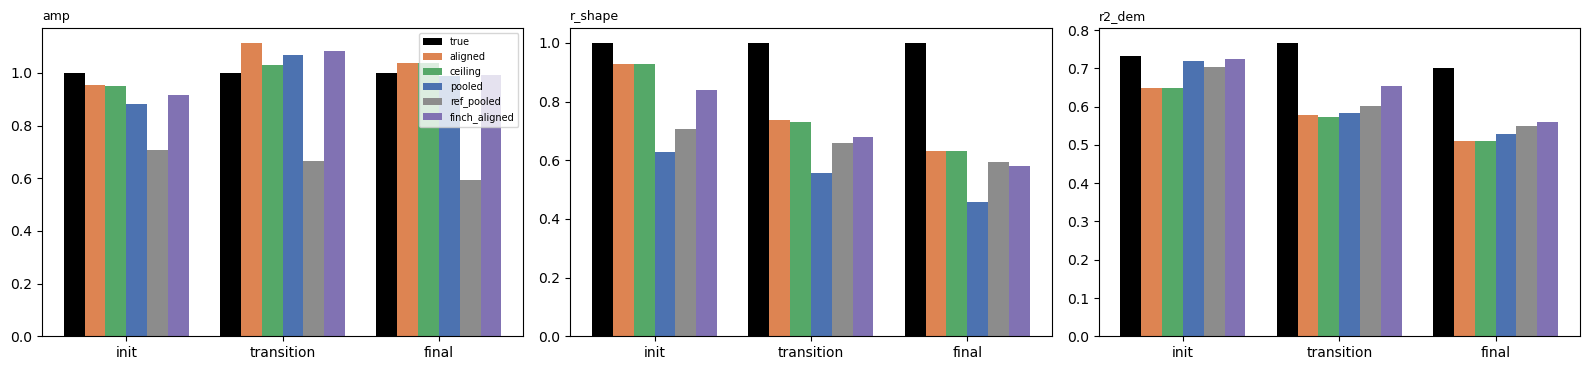

In [ ]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = {k: AL.analyse(world, CELLS[k], ALIGN168, store=store, server=True, n_perm=99)
          for k in RUNS}
display(pd.concat({k: v["summary"].set_index(["source", "phase"])[
    ["rmse", "r_shape", "amp", "r2_dem"]] for k, v in OUT168.items()}, axis=1).round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168[FOCUS]["summary"])
fig.tight_layout()
plt.show()

In [ ]:
_ = AL.aligned_browser(OUT168[FOCUS]["run"], OUT168[FOCUS]["fid"], channels)

## 7. Invariance across blocks

Per weekday·hour class, each 6-month block against the init reference (the block's own months
left out). `r_true` is the data side and is the same for every cell; `e_lat` and `r_dec` are
the representation, so they differ by schedule.

In [ ]:
BLOCK = 6
INV = {k: AL.invariance(world, OUTS[k]["run"], OUTS[k]["fw"], OUTS[k]["model"], channels,
                        block=BLOCK) for k in RUNS}
S_T = {k: AL.invariance_summary(v) for k, v in INV.items()}
INV_C = AL.invariance(world, san["control"].wt, fw, None, channels, block=BLOCK)

fig, axes = plt.subplots(len(S_T), 2, figsize=(16, 3.4 * len(S_T)), squeeze=False,
                         layout="constrained")
for i, (k, S) in enumerate(S_T.items()):
    im = AL.plot_invariance(axes[i, 0], S, "r_fid", "pure", vmin=-1, vmax=1)
    axes[i, 0].set_title(f"r_fid · pure · {k}", fontsize=9, loc="left")
    im2 = AL.plot_invariance(axes[i, 1], S, "e_lat", "pure", vmin=0, vmax=1, cmap="viridis")
    axes[i, 1].set_title(f"e_lat · {k}", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[:, 0], shrink=0.6, label="r_fid")
fig.colorbar(im2, ax=axes[:, 1], shrink=0.6, label="e_lat")
plt.show()

display(pd.concat({k: v.pivot_table(index=["client", "slot_class"], columns="phase",
                                    values=["r_true", "r_fid", "e_lat"])
                   for k, v in S_T.items()}, axis=1).round(3))

AttributeError: 'AlignedRun' object has no attribute 'columns'

## 8. Drift visibility — the comparison

Per (client, month), two signals from each cell:

* **reconstruction**: median `r` and `rmse` over that month's windows;
* **latent displacement**: `e_lat` $=\lVert z_m - z_{ref}\rVert / \lVert z_{ref}\rVert$ and
  `cos_lat`, against the client's own init mean latent.

`visibility` reduces each to one number,

$$z = \frac{\mathrm{median}_{post} - \mathrm{median}_{ref}}{\mathrm{IQR}_{ref}}$$

with `post` from `first_switch` on, and `r` negated so that positive always means "moved".
`contrast` is the drifting client's $z$ minus the largest of the others: **a schedule is good
for drift detection when contrast is large**, i.e. it moves for A and not for B, C, D.

For the streaming cell there is a stronger signal still: each block is scored **before** it is
trained on, so `prequential` is an out-of-sample curve over time, and the honest latents of
that moment are in `latent_trajectories_preq`.

In [ ]:
PROF = {k: CP.drift_profile(world, OUTS[k]["run"], OUTS[k]["fw"], channels,
                            slot_class="pure") for k in RUNS}
VIS = {k: CP.visibility(PROF[k], world) for k in PROF}

for sig in ("e_lat", "r"):
    print(f"--- z per client, signal = {sig}")
    display(CP.compare_visibility(VIS, world, sig).round(2))

for sig in ("e_lat", "r"):
    fig, axes = plt.subplots(1, len(PROF), figsize=(4.6 * len(PROF), 3.4), squeeze=False,
                             layout="constrained")
    CP.plot_profiles(axes[0], PROF, world, sig, slot_note=" · pure")
    plt.show()

In [ ]:
STREAM_CELLS = [k for k in RUNS if OUTS[k]["res"].get("prequential") is not None]
for k in STREAM_CELLS:
    preq = OUTS[k]["res"]["prequential"]
    display(preq.pivot_table(index=["block", "m_lo", "m_hi"], columns="model",
                             values=["r", "ratio"]).round(3))
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.4), layout="constrained")
    CP.plot_prequential(ax[0], preq, world, "r")
    CP.plot_prequential(ax[1], preq, world, "ratio")
    ax[0].set_title(f"{k} · unseen-block score", fontsize=9, loc="left")
    plt.show()

## What to read out of this

* **Which schedule wins on `contrast`?** That is the thesis-relevant number: drift visible in
  the drifting client, quiet elsewhere. The all-months model can absorb the drift (it trains
  on it), so the expectation is `comm` ≥ `stream` > `all` on reconstruction-based signals, and
  a smaller difference on latent displacement.
* **Fidelity is the counterweight.** A commissioning model should be the best on init months
  and the worst afterwards. If it is also worse on init (fewer windows, so fewer steps despite
  the matched budget), the comparison is about data volume, not the schedule.
* **Prequential is the only out-of-sample number here.** Everything else, in every cell, is
  in-sample.

**Open after this:**
* the weekend modulation is a fidelity gap, not an averaging one; the levers are a smaller
  stride, the spectral term, or explicit calendar conditioning of the decoder (upstream);
* bidirectional sensors need their own encoding (magnitude plus direction);
* `final` is one month in this world, so the post-drift side rests on the transition blocks;
* a world with distinct sector maps is still what the regime-recovery question needs.